# 02 · Ознаки з тексту: регулярні вирази, майже-дублікати, kNN-target

Табличних ознак (тип, вік, порода, RescuerID…) у цьому змаганні немає, але
частину з них можна **відновити з опису**. Крім того, в EDA ми побачили, що
багато описів — майже однакові (один волонтер, один шаблон), і таргет у таких
групах майже збігається. Це використовуємо через kNN-target ознаки,
пораховані **строго out-of-fold**.

Результат: `data/processed/text_feats_{train,test}.parquet`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from src.config import *
from src.utils import seed_everything, qwk, OptimizedRounder
from src.models import run_lgb_cv

seed_everything(SEED)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

In [2]:
from src.data import text_meta_features
from src.features import (text_regex_features, char_tfidf, normalize_text,
                          duplicate_groups, group_size, knn_target_features)

train = pd.read_parquet(PROCESSED_DIR / "train_meta.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_meta.parquet")
y = train[TARGET_COL].values
folds = train["fold"].values
all_text = pd.concat([train[TEXT_COL], test[TEXT_COL]], ignore_index=True)
n_tr = len(train)
print(train.shape, test.shape)

(6431, 12) (1891, 3)


In [3]:
def spearman_table(df: pd.DataFrame, y) -> pd.Series:
    """Spearman correlation of every column with the target (NaN filled with -1)."""
    return df.apply(lambda c: spearmanr(c.fillna(-1), y)[0]).sort_values()

## 1. Ознаки з регулярних виразів

Ключові слова (кіт/собака, малюк/дорослий, порода, здоров'я, стерилізація, внесок…),
розпарсений вік у місяцях, кількість тварин в оголошенні, ознаки мови.

In [4]:
# Simple length/case stats from EDA + regex features, for train and test alike
regex_all = pd.concat([text_meta_features(all_text), text_regex_features(all_text)], axis=1)
regex_tr, regex_te = regex_all.iloc[:n_tr].reset_index(drop=True), regex_all.iloc[n_tr:].reset_index(drop=True)
regex_tr.describe().T[["mean", "50%", "max"]].round(3)

,mean,50%,max
desc_len,364.185,250.000,5798.0
desc_words,67.442,46.000,1153.0
desc_upper_ratio,0.039,0.025,1.0
desc_excl,0.369,0.000,21.0
desc_digits,1.461,0.000,38.0
desc_is_empty,0.001,0.000,1.0
desc_non_ascii,0.005,0.000,1.0
kw_cat,0.832,0.000,35.0
kw_dog,0.858,0.000,20.0
kw_baby,0.752,0.000,22.0


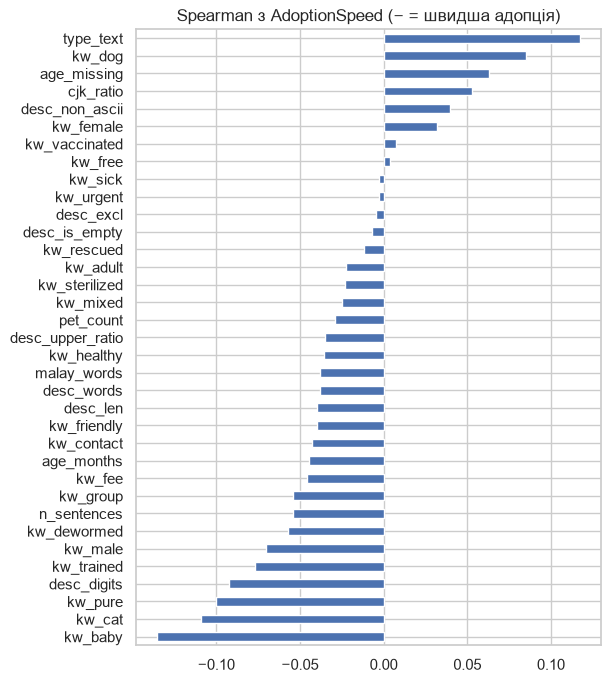

In [5]:
corr = spearman_table(regex_tr, y)
corr.plot.barh(figsize=(6, 8), title="Spearman з AdoptionSpeed (− = швидша адопція)");

In [6]:
# Parsed age vs target (age is found in ~28% of descriptions)
age_bins = pd.cut(regex_tr["age_months"], [0, 2, 4, 6, 12, 24, 300])
train.groupby(age_bins, observed=True)[TARGET_COL].agg(["mean", "size"]).round(2)

,mean,size
age_months,,
"(0, 2]",2.38,987
"(2, 4]",2.70,261
"(4, 6]",2.66,202
"(6, 12]",3.11,159
"(12, 24]",3.05,63
"(24, 300]",2.73,117


## 2. Майже-дублікати описів

Char n-gram TF-IDF → косинусна схожість → компоненти зв'язності графа
«схожість ≥ 0.9». Розмір групи (по train+test, без міток) — проксі активності
волонтера (у вихідному змаганні кількість оголошень від одного RescuerID була
однією з найсильніших ознак).

In [7]:
X_char = char_tfidf(all_text)
valid = (normalize_text(all_text).str.len() >= 5).to_numpy()   # empty descriptions are not duplicates
groups = duplicate_groups(X_char, valid, threshold=0.9)
dup_size = group_size(groups)

g_tr = pd.DataFrame({"g": groups[:n_tr], "y": y, "size": dup_size[:n_tr]})
multi = g_tr[g_tr["size"] > 1]
print("train pets in duplicate groups:", len(multi), f"({len(multi) / n_tr:.1%})")
print("test pets with a duplicate in train:", np.isin(groups[n_tr:], groups[:n_tr]).sum())
print("mean target std inside groups:", multi.groupby("g")["y"].std().mean().round(3),
      " vs global std:", y.std().round(3))

train pets in duplicate groups: 811 (12.6%)
test pets with a duplicate in train: 208
mean target std inside groups: 0.266  vs global std: 1.119


In [8]:
# Example: the largest group
big = pd.Series(groups).value_counts().index[0]
ex = pd.concat([train, test], ignore_index=True).loc[groups == big, [ID_COL, TEXT_COL, TARGET_COL]]
print("size:", len(ex)); ex.head(5)

size: 96


,PetID,Description,AdoptionSpeed
214,a4ade8bb2,For Adoption,1.0
221,66064ba80,FOR ADOPTION,2.0
653,b49012dd4,For Adoption,2.0
686,ac6adc2e4,For Adoption,2.0
710,0910c13a3,For adoption,4.0


## 3. kNN-target ознаки (out-of-fold)

Для кожної тварини шукаємо 5 найближчих описів **серед train з інших фолдів**
(для test — серед усього train) і беремо середній таргет, зважений `sim⁴`
(майже-дублікати домінують). Фолди стратифіковані випадкові — так само, як
випадковий поділ train/test, тож OOF-оцінка чесна.

In [9]:
knn_tr, knn_te = knn_target_features(
    X_char[:n_tr], X_char[n_tr:], y, folds, prefix="txt",
    train_valid=valid[:n_tr], test_valid=valid[n_tr:],
)
spearman_table(knn_tr, y)

txt_knn_mean_sim   -0.023655
txt_nn1_sim        -0.022908
txt_nn1_y           0.209270
txt_knn_y           0.290086
dtype: float64

## 4. Збірка та швидка перевірка сигналу

LightGBM тільки на цих ознаках + мета-ознаки з EDA (без TF-IDF/SVD — це буде в бейзлайні).

In [10]:
meta_cols = ["n_photos"]

text_tr = pd.concat([train[[ID_COL]].reset_index(drop=True), regex_tr, knn_tr.reset_index(drop=True)], axis=1)
text_te = pd.concat([test[[ID_COL]].reset_index(drop=True), regex_te, knn_te.reset_index(drop=True)], axis=1)
text_tr["txt_dup_size"], text_te["txt_dup_size"] = dup_size[:n_tr], dup_size[n_tr:]

feat_cols = [c for c in text_tr.columns if c != ID_COL]
X_tr = pd.concat([train[meta_cols].reset_index(drop=True), text_tr[feat_cols]], axis=1)
X_te = pd.concat([test[meta_cols].reset_index(drop=True), text_te[feat_cols]], axis=1)

res_no_knn = run_lgb_cv(X_tr.drop(columns=knn_tr.columns), X_te.drop(columns=knn_tr.columns), y, folds, verbose=False)
res = run_lgb_cv(X_tr, X_te, y, folds)
print(f"\nOOF QWK without kNN: {res_no_knn['qwk']:.4f}   with kNN: {res['qwk']:.4f}")

fold 0: best_iter= 156  rmse=1.0445


fold 1: best_iter= 201  rmse=1.0439


fold 2: best_iter= 365  rmse=1.0184


fold 3: best_iter= 213  rmse=1.0316


fold 4: best_iter= 154  rmse=1.0367


OOF QWK: 0.3189   thresholds: [1.665 2.672 2.919]

OOF QWK without kNN: 0.2458   with kNN: 0.3189


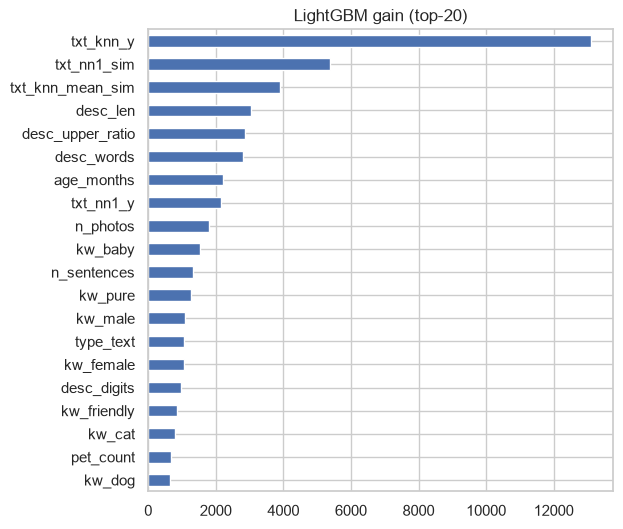

In [11]:
res["importance"].head(20).plot.barh(figsize=(6, 6), title="LightGBM gain (top-20)").invert_yaxis();

In [12]:
text_tr.to_parquet(PROCESSED_DIR / "text_feats_train.parquet", index=False)
text_te.to_parquet(PROCESSED_DIR / "text_feats_test.parquet", index=False)
print(text_tr.shape, text_te.shape)

(6431, 41) (1891, 41)


## Висновки

- **Regex-ознаки** відновлюють частину табличних даних: найкорисніші — «малюк» (kitten/puppy, ρ = −0.135),
  тип тварини (коти адоптуються швидше, ρ ≈ 0.11), згадка породи (ρ = −0.10). Вік вдається розпарсити
  лише у 28 % описів, але він інформативний: до 2 місяців середній клас 2.38, 6–12 місяців — 3.11.
  Телефони й переноси рядків організатори з текстів видалили.
- **Майже-дублікати — головна знахідка:** 12.6 % train входять у групи майже однакових описів
  (один волонтер, один шаблон), і таргет усередині групи майже збігається (std 0.27 проти 1.12).
  208 тварин test мають «двійника» в train. Найбільша група (96 оголошень) — просто «For Adoption»,
  тож розмір групи сам по собі не корисний.
- **Валідація:** оскільки train/test поділено випадково, звичайні стратифіковані фолди відтворюють ту саму
  частку двійників — групові фолди тут занижували б оцінку і ховали б реальний сигнал.
- **kNN-target (OOF):** середній таргет найближчих описів з *інших* фолдів — ρ = 0.29 з таргетом
  (найкраща окрема ознака з тексту). LightGBM тільки на текстових ознаках: **0.246 → 0.319** з kNN.
- Текст загалом дає помірний сигнал — стеля текстових моделей у проєкті виявилась ~0.35.